# This notebook is for computing the Eros metric for events where the BES diagnostic was near the pedestal top. H mode is not included in the analysis

In [1]:
import os #allow for multithreading in numpy
%env OMP_NUM_THREADS = 32
%env OPENBLAS_NUM_THREADS = 32
%env MKL_NUM_THREADS = 32
%env VECLIB_MAXIMUM_THREADS = 32
%env NUMEXPR_NUM_THREADS = 32
import numpy as np
import pandas as pd
import scipy
import matplotlib.patches as mpatches
import matplotlib.ticker as tkr
import matplotlib.pyplot as plt
import custom_functions.data_processing_functions as dpf
import custom_functions.cluster_analysis_functions as cluster_func
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import davies_bouldin_score
import h5py


env: OMP_NUM_THREADS=32
env: OPENBLAS_NUM_THREADS=32
env: MKL_NUM_THREADS=32
env: VECLIB_MAXIMUM_THREADS=32
env: NUMEXPR_NUM_THREADS=32


In [2]:
plt.rcParams.update({'font.size': 20})


In [3]:
Eros_dissimilarity_matrix = np.load('custom_functions/elm_free_supplement_functions/Eros_R_edge_all_dissimilarity_matrix.npy')
#spike

# bes_path = 'computed_matrices/elm_free_matrices/elm_free_bes_dict_filtered_new_start.npy'
# bes_dict = np.load(bes_path, allow_pickle=True).item()
# Eros_dict = np.load('computed_matrices/elm_free_matrices/elm_free_eros_dict_filtered_new_start.npy', allow_pickle=True).item()
# pedestal_dict = pedestal_dict = np.load('elm_free_bes_data/all_pedestal_dict_elm_free.npy', allow_pickle=True).item()
# acceptable_ids_dict = np.load('elm_free_bes_data/bes_sensors_in_pedestal_top.npy', allow_pickle=True).item()
# #parameter dict with shaping, and q95 for the elm free dict
# elm_free_param_dict = np.load('ELM_free_data_analysis/elm_free_param_dict.npy', allow_pickle=True).item()

#no spike

Eros_dict = np.load('computed_matrices/elm_free_matrices/Eros_dict_edge_all_sensors.npy', allow_pickle=True).item()
pedestal_dict = np.load('elm_free_bes_data/all_pedestal_dict_elm_free.npy', allow_pickle=True).item()
acceptable_ids_dict = np.load('computed_matrices/elm_free_matrices/bes_sensors_in_edge.npy', allow_pickle=True).item()
#parameter dict with shaping, and q95 for the elm free dict
elm_free_param_dict = np.load('ELM_free_data_analysis/elm_free_param_dict.npy', allow_pickle=True).item()
new_start_times_dict = np.load('elm_free_bes_data/new_start_times_elm_free.npy', allow_pickle=True).item()

In [4]:
np.shape(Eros_dict['00001']['V'])

(64, 64)

In [5]:
bes_path = 'computed_matrices/elm_free_matrices/elm_free_bes_dict_filtered_new_start_no_spike.npy'
bes_dict = np.load(bes_path, allow_pickle=True).item()

In [6]:
event_ids = np.load('computed_matrices/elm_free_matrices/ids_in_edge_all.npy', allow_pickle=True)
print(len(event_ids))


441


In [7]:
print(np.shape(Eros_dissimilarity_matrix))


(441, 441)


In [8]:
print(np.argmax(Eros_dissimilarity_matrix)) #need to mod this by the length of pairs since the matrix is symmetric


24224


# Eros dissimilarity matrix 

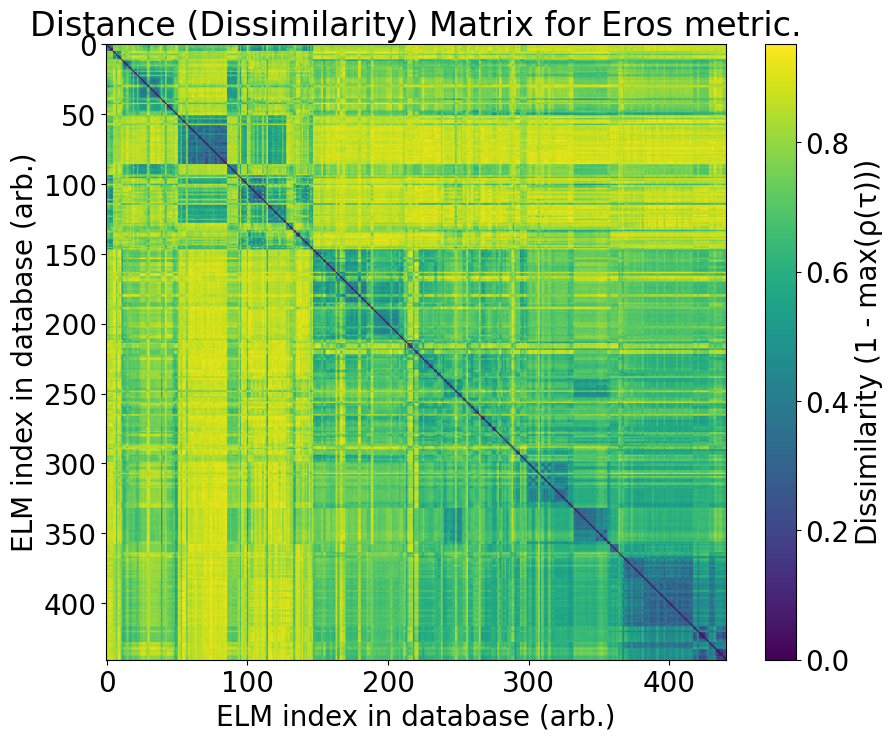

In [9]:
plt.figure(figsize=(10, 8))
plt.imshow(Eros_dissimilarity_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Dissimilarity (1 - max(ρ(τ)))')
# plt.clim(0, )  # Adjust the values to increase contrast
plt.title('Distance (Dissimilarity) Matrix for Eros metric.') 
plt.xlabel('ELM index in database (arb.)')
plt.ylabel('ELM index in database (arb.)')
plt.savefig('Distance (Dissimilarity) Matrix for Eros metric.')
plt.show()

In [10]:
linked_Eros = linkage(squareform(Eros_dissimilarity_matrix), method = 'ward') #need to transform from a distance matrix to a feature vector

In [11]:
print(np.shape(linked_Eros))


(440, 4)


[ 2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]


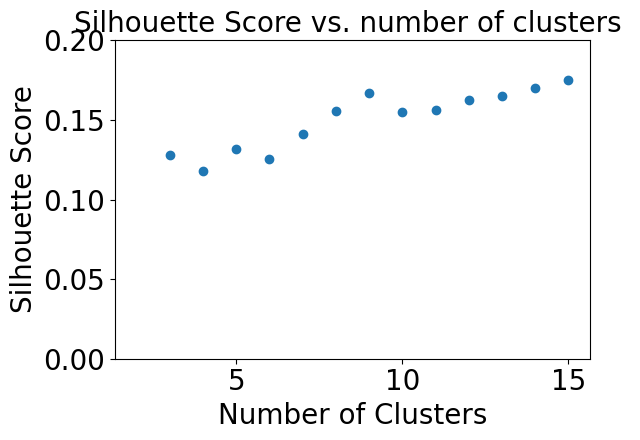

In [12]:
sil_score_arr = cluster_func.silhouette_comparison(Eros_dissimilarity_matrix)

sil_clusters = np.linspace(2,len(sil_score_arr)+1, len(sil_score_arr))
print(sil_clusters)
plt.figure(figsize = (6.4,4.8))
plt.title('Silhouette Score vs. number of clusters ', size = 20)
plt.xlabel('Number of Clusters', size = 20)
plt.ylabel('Silhouette Score', size = 20)
plt.scatter(sil_clusters, sil_score_arr)
plt.tight_layout()
# plt.savefig('APS_figures/ELM_free_Eros_silhouette_score.pdf', dpi = 600, transparent = True)
# plt.xlim([3,15])
plt.ylim([0,.2])
plt.show()

# Based on the elbow in the above graph, we can pick a threshold in the dendrogram to achieve the "optimal" number of clusters

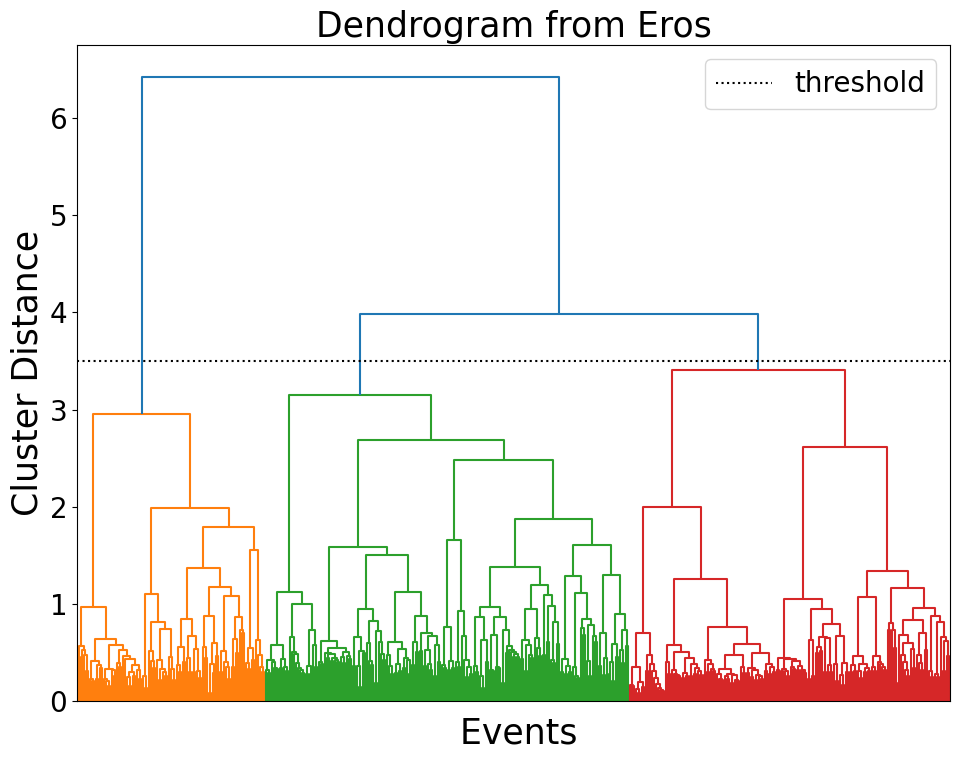

In [13]:
threshold = 3.5
plt.figure(figsize = (10,8))
dendrogram(linked_Eros,
    orientation='top',
    labels=event_ids,
    leaf_rotation=90,
    color_threshold= threshold
)
plt.axhline(threshold, c = 'k', linestyle = ':', label = 'threshold')
plt.gca().set_xticklabels([])
plt.yticks(fontsize = 20)
plt.xlabel(' Events', fontsize = 25)
plt.ylabel('Cluster Distance', fontsize = 25)
plt.title('Dendrogram from Eros', fontsize = 25)
plt.tight_layout()
plt.savefig('APS_figures/Dendrogram_ELM_free_Eros_all_sensors_edge_BES.pdf', dpi = 600, transparent = True)
plt.legend(fontsize = 20)

In [14]:
num_clusters_new = 4 #these are just selected based off of the number of colors in the dendrogram for each linkage matrix


labels_new = fcluster(linked_Eros, t = num_clusters_new, criterion = 'maxclust')

print(len(labels_new))

441


In [15]:
keys_new = [str(i) for i in range(1, num_clusters_new+1)]



In [16]:
cluster_save_path = f'bes_top_clusters_{num_clusters_new}.npy'
cluster_dict_new = {}
for key in keys_new:
    cluster_dict_new[key] = []


In [17]:
for index, label in enumerate(labels_new):
    elm_index = event_ids[index]
    cluster_dict_new[str(label)].append(elm_index) #assign event ids to the clusters in the dictionary for the old Eros method
np.save(cluster_save_path, cluster_dict_new, allow_pickle=True)
print('cluster dict saved')

cluster dict saved


# How well does hierarchical clustering seperate between the different kinds of regimes that are present in the data?

# This run does not include H mode so we comment this out

In [18]:
L_count = 0
QH_count = 0
WPQH_count = 0
for id in event_ids:
    label = bes_dict[id]['label']
    if label == 0:
        L_count+=1
    if label == 2:
        QH_count+=1
    if label == 3:
        WPQH_count+=1

print(f'L count: {L_count}')
print(f'QH count: {QH_count}')
print(f'WPQH count: {WPQH_count}')

L_shots = []
QH_shots = []
WPQH_shots = []
for id in event_ids:
    label = bes_dict[id]['label']
    shot = bes_dict[id]['shot']
    if label == 0 and shot not in L_shots:
        L_shots.append(shot)
    if label == 2 and shot not in QH_shots:
        QH_shots.append(shot)
    if label == 3 and shot not in WPQH_shots:
        WPQH_shots.append(shot)



print(f'L shots: {len(L_shots)}')
print(f'QH shots: {len(QH_shots)}')
print(f'WPQH shots: {len(WPQH_shots)}')

L count: 147
QH count: 147
WPQH count: 147
L shots: 42
QH shots: 92
WPQH shots: 26


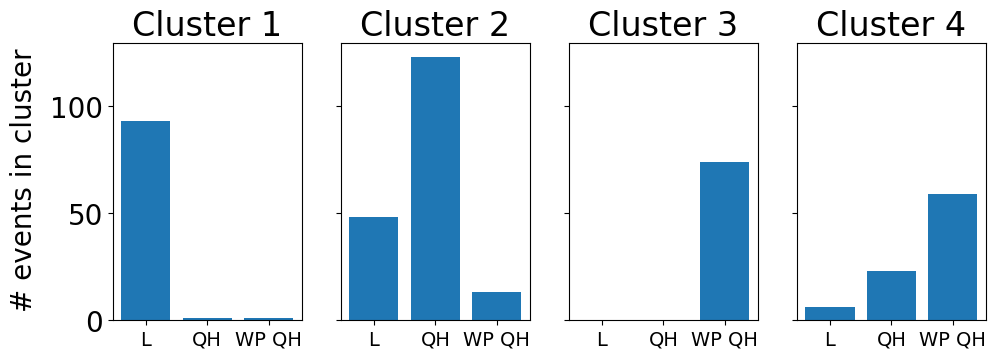

In [19]:
if num_clusters_new < 5:
    regimes = ['L', 'QH', 'WP QH']
    fig,axs = plt.subplots(1,4, figsize = (10,4), sharey=True)
    axs = axs.flatten()
    for i,cluster in enumerate(cluster_dict_new.keys()): #cycle over all clusters
        #count the number of items in the cluster that correspond to each regime
        L_mode_counter = 0
        #H_mode_counter = 0
        QH_counter = 0
        WP_counter = 0

        for id in cluster_dict_new[cluster]: #cycle over all ids  in the cluster
            label = bes_dict[id]['label']
            if label == 0:
                L_mode_counter +=1
            #if label == 1:
                #H_mode_counter+=1
            if label == 2:
                QH_counter+=1
            if label == 3:
                WP_counter+=1
        #plot in a bar chart

        axs[i].set_title(f'Cluster {cluster}')
        axs[i].bar(regimes, [L_mode_counter, QH_counter, WP_counter])
        axs[i].tick_params(axis="x", labelsize=14)

    fig.text(-.01, 0.5, '# events in cluster', va='center', rotation='vertical', fontsize = 20)
    # fig.suptitle('BES pedestal top')
    fig.tight_layout()
    # if num_clusters_new % 2 == 1:
        # fig.delaxes(axs[-1])
    fig.savefig(f'Paper_figures/ELM_free_regimes_{num_clusters_new}_clusters_all_sensors_edge_BES.pdf', dpi = 600, transparent=True, bbox_inches = 'tight')

In [20]:
if num_clusters_new > 4:
    regimes = ['L', 'QH', 'WP QH']
    fig,axs = plt.subplots(2,5, figsize = (12,8), sharey=True)
    axs = axs.flatten()
    for i,cluster in enumerate(cluster_dict_new.keys()): #cycle over all clusters
        #count the number of items in the cluster that correspond to each regime
        L_mode_counter = 0
        #H_mode_counter = 0
        QH_counter = 0
        WP_counter = 0

        for id in cluster_dict_new[cluster]: #cycle over all ids  in the cluster
            label = bes_dict[id]['label']
            if label == 0:
                L_mode_counter +=1
            #if label == 1:
                #H_mode_counter+=1
            if label == 2:
                QH_counter+=1
            if label == 3:
                WP_counter+=1
        #plot in a bar chart

        axs[i].set_title(f'Cluster {cluster}')
        axs[i].bar(regimes, [L_mode_counter, QH_counter, WP_counter])
        axs[i].tick_params(axis="x", labelsize=14)

    fig.text(-.01, 0.5, '# events in cluster', va='center', rotation='vertical', fontsize = 20)
    # fig.suptitle('BES pedestal top')
    fig.tight_layout()
    # if num_clusters_new % 2 == 1:
        # fig.delaxes(axs[-1])
    fig.savefig(f'Paper_figures/ELM_free_regimes_{num_clusters_new}_4_clusters_all_sensors_edge.pdf', dpi = 600, transparent=True, bbox_inches = 'tight')

In [21]:
for id in cluster_dict_new['3']:
    good_sensors = []
    if bes_dict[id]['label'] == 2:
        for k in range(64):
            if acceptable_ids_dict[id][k,0] != -1:
                good_sensors.append(k+1)
        print(id)
        print(
            f'shot: {bes_dict[id]['shot']} has good sensors at {good_sensors}. from t start:',
            f'{new_start_times_dict[id]['new_start']} to {new_start_times_dict[id]['new_stop']} id: {id}. ped top at {pedestal_dict[id]['pe']['top']}')
        
        print(f'id : {id} has a sensor at {acceptable_ids_dict[id][good_sensors[0]-1]}')

Some shots with confinement factor above 1.1. in cluster 3
'159543' - no EHO during event

'175530' - no EHO

'159531' - all noise

'175527' - no EHO

In [132]:
avg_dissimilarity = np.zeros(num_clusters_new)
for i,cluster in enumerate(labels_new):
    id = event_ids[i]
    

In [133]:
if num_clusters_new > 3:
    for id in cluster_dict_new['4']:
        good_sensors = []
        if bes_dict[id]['label'] == 3:
            for k in range(64):
                if acceptable_ids_dict[id][k,0] != -1:
                    good_sensors.append(k+1)
            print(
                f'shot: {bes_dict[id]['shot']} has good sensors at {good_sensors}. from t start:',
                f'{bes_dict[id]['time'][0]} to {bes_dict[id]['time'][-1]} id: {id}. ped top at {pedestal_dict[id]['pe']['top']}')
            print(f'id : {id} has a sensor at {acceptable_ids_dict[id][good_sensors[0]-1]}')

shot: 157109 has good sensors at [1, 9, 17, 32, 33, 41, 49, 57]. from t start: 2700.0 to 2929.599 id: 00035. ped top at 0.787294143845262
id : 00035 has a sensor at [0.86124994 0.06146876]
shot: 157109 has good sensors at [1, 9, 18, 33, 34, 42, 50, 58]. from t start: 2940.759 to 2964.899 id: 00036. ped top at 0.7611713749212878
id : 00036 has a sensor at [0.79226721 0.06088548]
shot: 157109 has good sensors at [1, 9, 18, 33, 34, 42, 50, 58]. from t start: 2980.761 to 2998.899 id: 00037. ped top at 0.7611020340411396
id : 00037 has a sensor at [0.79076072 0.06113453]
shot: 157109 has good sensors at [1, 9, 17, 32, 33, 41, 49, 57]. from t start: 3500.76 to 3504.599 id: 00041. ped top at 0.7890936527940597
id : 00041 has a sensor at [0.86598637 0.05975145]
shot: 157109 has good sensors at [1, 9, 17, 33, 41, 42, 49, 57]. from t start: 3540.759 to 3546.099 id: 00042. ped top at 0.7473605579270239
id : 00042 has a sensor at [0.7985383  0.05972567]
shot: 163505 has good sensors at [2, 10, 18,

# All below this cell is from the elm free data. Let's neglect the comparrison of plasma paramters for a second and just see if these clusters can reasonably identify the difference between the different kinds of discharges

# I would like to reproduce the plots in the 2016 ELM classification paper that indicate if the clusters found by the algorithm actually meaningfully represent different clusters or not. I'm going to try to pull in some plasma parameters and get the average values of that parameter over the different events in each cluster

 # The parameters of interest (from the 2016 paper) are:
- Plasma Current
- Toroidal B fieid
- Neutral beam power
- magnetic balence d_{r}^{sep}
- safety factor q_{95}
- Stored energy W_{dia}
- Stored energy loss W_{loss}
- Elongation \kappa
- Lower triangularity \delta_l
- Pedestal ele. den. height, ne  ped (10 /cm  13 3)
- Pedestal ele. den. width, ∆Rne  ped
- Pedestal ele. temp. height, Te  ped (keV)
- Pedestal ele. temp. width, ∆RTe  ped (cm)
- Zeff
- Collisionality, νei (10^6)
- Total beta, β = 2μ (2p )/B  e  0  ped 2
- Poloidal beta, β = 2μ (2p )/B  p ep  0  ped 2
- Alfvén time, τ = R /v  A 0 A (μs)

# We don't seem to have a lot of these! I'll start by loading in:
- Toroidal B
- Plasma current
- ECH power
- neutral beam power

# Distribution of freqeuncies in each cluster (PSD). Need to do a comparison between the channels that actually got compared for each pair of ids

In [134]:
boxplot_style = {
    'whiskerprops': {'linewidth': 1.5},
    'medianprops': {'linewidth': 2},
    'capprops': {'linewidth': 1.5},
    'boxprops': {'linewidth': 1.5}
}

In [135]:
def psd_regime_across_cluster(regime, clusters, cluster_dict, bes_dict,acceptable_ids_dict):
    '''
    This function is for computing the PSD for the events in each cluster from a certain regime
    regime: str. 'L', 'QH', 'WPQH'
    clusters: list. list of ints where each int represents the cluster
    cluster_dict: dict. each key is a cluster, the value is a list of ids in that cluster
    bes_dict. dict. each key is an id, within that are the signals, and regime labels
    acceptable_ids_dict: dict. Each key is an id, each value is a 64x2 array of BES coordinates. If the r component of the arr
    is -1, then the sensor was not used in the analysis

    returns: 
    regime_fft_dict. Dict. Contains average peak of PSD for each sensor used for Eros analysis in each event
    bandwidth_dict: dict. Contains the bandwidth where 99 percent of the signal energy is
    '''
    labels = {0: 'L', 1: 'H', 2: 'QH', 3:'WPQH'}
    regime_fft_dict = {}
    bandwidth_dict = {}
    for cluster in clusters:
        regime_fft_dict[cluster] = []
        bandwidth_dict[cluster] = []
        for id in cluster_dict[str(cluster)]:
            num_sensors = 0
            if labels[bes_dict[id]['label']] == regime:
                good_sensors = list(np.where(acceptable_ids_dict[id][:,0] != -1)[0])
                max_f_arr = np.zeros(len(good_sensors))
                bandwidth_arr = np.zeros(len(good_sensors))
                for i,k in enumerate(good_sensors):
                    num_sensors+=1
                    signal = bes_dict[id]['signals'][k,:] - np.mean(bes_dict[id]['signals'][k,:])
                    dt = (bes_dict[id]['time'][1] - bes_dict[id]['time'][0])/1000
                    fs = 1/dt
                    # freqs = np.fft.fftfreq(signal.size, 1/fs)
                    # freqs_shift = np.fft.fftshift(freqs)
                    # fft_signal = np.fft.fft(signal)
                    f,PSD = scipy.signal.welch(signal, fs, nperseg = 1024)
                    total_power = np.sum(PSD)
                    cum_power = np.cumsum(PSD)
                    norm_cum_power = cum_power/total_power
                    cutoff_low = f[np.searchsorted(norm_cum_power, .05)]
                    cutoff_high =  f[np.searchsorted(norm_cum_power, .995)]
                    bandwidth_arr[i] = (cutoff_high + cutoff_low)/2
                    max_f_arr[i] = f[np.argmax(PSD)]
                    # if f[np.argmax(PSD)] > 100000:
                    #     print(f'id {id} at sensor {k}. shot {bes_dict[id]['shot']}. t = {bes_dict[id]['time'][0]} - {bes_dict[id]['time'][-1]}')
                regime_fft_dict[cluster].append(np.median(max_f_arr))
                bandwidth_dict[cluster].append(np.median(bandwidth_arr))

            else:
                continue
            
            # print(f'{id} has {num_sensors} good sensors')
    return regime_fft_dict, bandwidth_dict

In [136]:
def signal_intensity(regime, clusters, cluster_dict, bes_dict,acceptable_ids_dict):
    labels = {0: 'L', 1: 'H', 2: 'QH', 3:'WPQH'}
    intensity_dict = {}
    for cluster in clusters:
        intensity_dict[cluster] = []
        for id in cluster_dict[str(cluster)]:
            if labels[bes_dict[id]['label']] == regime:
                good_sensors = list(np.where(acceptable_ids_dict[id][:,0] != -1)[0])
                intensity = 0
                for i,k in enumerate(good_sensors):
                    signal = bes_dict[id]['signals'][k,:]
                    intensity += np.linalg.norm(signal)
                intensity = intensity/len(good_sensors)
                intensity_dict[cluster].append(intensity)
            else:
                continue
    return intensity_dict

In [137]:
def regime_comparison(data_dict, bes_dict, cluster_dict, regime, num_missing = False):
    '''
    This script is for comparing different distributions of parameters across the different regimes from cluster to cluster
    data_dict: dict. Contains as keys the ids, and as values the parameter
    bes_dict: dict containing labels for each regime corresponding to the ids in each part of the database
    cluster_dict: each key is a cluster and the values are the ids in that cluster
    regime: string that will correspond to L, H, QH, WPQH
    '''
    cross_cluster_regime_dict = {}
    regime_dict = {'L': 0, 'H': 1,'QH': 2, 'WPQH': 3}
    missing = []
    for cluster in cluster_dict:
        cross_cluster_regime_dict[cluster] = []
        for id in cluster_dict[cluster]:
            label = bes_dict[id]['label']
            if label != regime_dict[regime]:
                continue
            if bool(data_dict[id]) == False:
                missing.append(id)
                continue
            if isinstance(data_dict[id], dict):
                cross_cluster_regime_dict[cluster].append(data_dict[id]['signals'])
            else:
                if isinstance(data_dict[id],str):
                    continue
                else:
                    cross_cluster_regime_dict[cluster].append(data_dict[id])
        
    if num_missing:
        return cross_cluster_regime_dict, missing
    else:
        return cross_cluster_regime_dict

In [138]:
def boxplot_maker(dicts, regimes, title, value, ylim = 0):
    '''
    dicts: list of the dictionaries to be compared
    regimes: list of the order of the regimes that are in 'dicts'
    title: title of figure
    value: str for the y axis label
    '''
    fig,axs = plt.subplots(1, len(dicts), figsize = (10,6),sharey=True)
    if len(dicts) == 1:
        axs = [axs]
    axs[0].set_ylabel(value)
    for i,ax in enumerate(axs):
        ax.boxplot(dicts[i].values(), **boxplot_style)
        ax.set_xlabel('Clusters')
        if ylim:
            ax.set_ylim([0, ylim])
        ax.set_title(regimes[i])
    fig.suptitle(title)
    fig.tight_layout()
    

In [139]:
L_mode_intensity_dict = signal_intensity('L', [int(cluster) for cluster in cluster_dict_new.keys()], cluster_dict_new, bes_dict, acceptable_ids_dict)
QH_mode_intensity_dict = signal_intensity('QH', [int(cluster) for cluster in cluster_dict_new.keys()], cluster_dict_new, bes_dict, acceptable_ids_dict)
WPQH_mode_intensity_dict = signal_intensity('WPQH', [int(cluster) for cluster in cluster_dict_new.keys()], cluster_dict_new, bes_dict, acceptable_ids_dict)

In [140]:
signal = bes_dict['00009']['signals'][4,:]
dt = (bes_dict['00009']['time'][1] - bes_dict['00009']['time'][0]) / 1000
fs = 1/dt
f,PSD = scipy.signal.welch(signal, fs)
total_power = np.sum(PSD)
cum_power = np.cumsum(PSD)
norm_cum_power = cum_power/total_power

cutoff_low = np.searchsorted(norm_cum_power, .05)
cutoff_high =  np.searchsorted(norm_cum_power, .995)

print(f[cutoff_low])
print(f[cutoff_high])

3906.250000980549
140625.00003529977


In [141]:
QH_mode_max_freq_dict, QH_mode_bandwidth_dict = psd_regime_across_cluster('QH', [int(cluster) for cluster in cluster_dict_new.keys()], cluster_dict_new, bes_dict, acceptable_ids_dict)
L_mode_max_freq_dict, L_mode_bandwidth_dict = psd_regime_across_cluster('L', [int(cluster) for cluster in cluster_dict_new.keys()], cluster_dict_new, bes_dict, acceptable_ids_dict)
WPQH_mode_max_freq_dict, WPQH_mode_bandwidth_dict = psd_regime_across_cluster('WPQH', [int(cluster) for cluster in cluster_dict_new.keys()], cluster_dict_new, bes_dict, acceptable_ids_dict)

/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 1024 is greater than input length  = 240, using nperseg = 240
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 1024 is greater than input length  = 740, using nperseg = 740
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


In [142]:
h98_dict = np.load('elm_free_bes_data/H98_dict_elm_free.npy', allow_pickle = True).item()
betan_dict = np.load('elm_free_bes_data/beta_dict_elm_free.npy', allow_pickle = True).item()
h98_cluster_dict = {}
for cluster in cluster_dict_new:
    h98_cluster_dict[cluster] = []
    for id in cluster_dict_new[cluster]:
        if h98_dict[id] == 'NA':
            continue
        else:
            h98_cluster_dict[cluster].append(h98_dict[id])
betan_cluster_dict = {}
for cluster in cluster_dict_new:
    betan_cluster_dict[cluster] = []
    for id in cluster_dict_new[cluster]:
        if h98_dict[id] == 'NA':
            continue
        else:
            betan_cluster_dict[cluster].append(betan_dict[id])

In [143]:
h98_vals = [h98_dict[id] for id in h98_dict.keys() if h98_dict[id] != 'NA']

print(np.min(h98_vals))

0.0


In [144]:
# weird_QH = []
# weird_QH_shots = []
# for id in h98_dict.keys():
#     label = bes_dict[id]['label']
#     if label == 2 and id in cluster_dict_new['3']:
#         if isinstance(h98_dict[id], str):
#             continue
#         elif h98_dict[id] > 1.1:
#             print(bes_dict[id]['shot'])
#             weird_QH_shots.append(bes_dict[id]['shot'])
#             weird_QH.append(id)
# weird_QH_shots = list(set(weird_QH_shots))
# # print(len(weird_QH_shots))

In [145]:
signal = bes_dict['00859']['signals']
fft = np.real(scipy.fft.rfft(signal, axis = 1, workers = 20))
n = len(signal[0,:])
timestep = (bes_dict[id]['time'][1] - bes_dict[id]['time'][0])/1000
d = (bes_dict[id]['time'][1] - bes_dict[id]['time'][0])/1000
freqs = scipy.fft.fftfreq(len(bes_dict[id]['signals'][0,:]), d)
freq_shift = scipy.fft.fftshift(freqs)
pos_freq = freq_shift[freq_shift >= 0]
pos_mask = freq_shift >=0
freq_pos = freq_shift[pos_mask]
freq_range = np.where(np.logical_and(freq_pos >=5000,freq_pos <=20000))
freq_5_20 = freq_pos[freq_range]
fft_5_20 = fft[:,freq_range].reshape(len(fft[:,0]), len(freq_5_20))

# plt.scatter(freq_5_20, fft_5_20[10,:])


In [146]:
def calculate_average_coherent_power(f, Sxx, f_min=5000, f_max=20000, noise_percentile=10):
    """
    Calculates the average power of coherent modes within a frequency band 
    by subtracting the underlying broadband noise floor. 
    """
    # 1. Create a boolean mask for the desired frequency band
    freq_mask = (f >= f_min) & (f <= f_max)
    Sxx_band = Sxx[freq_mask, :]
    
    # 2. Estimate the background noise floor over time using a low percentile
    noise_floor_vs_time = np.percentile(Sxx_band, noise_percentile, axis=0)
    
    # 3. Subtract the noise floor and clip negative subtraction artifacts to 0
    Sxx_modes_only = np.clip(Sxx_band - noise_floor_vs_time, a_min=0, a_max=None)
    
    # 4. Calculate the frequency step size
    df = f[1] - f[0]
    
    # 5. Integrate across frequency (axis=0) to get Coherent Power vs. Time
    power_vs_time = np.sum(Sxx_modes_only, axis=0) * df
    
    # 6. Average the power across all time steps
    average_power = np.mean(power_vs_time)
    
    return average_power, noise_floor_vs_time

# Example usage:
# Note: We no longer even need to pass the time array 't' into the function!
# id = '00859' #cluster 2. coherent
id = '00028' #cluster 3. mixed
signal = bes_dict[id]['signals']
shot = bes_dict[id]['shot']
f, t, Sxx = scipy.signal.spectrogram(signal[48,:], fs, nperseg=2048, noverlap=1740)
Sxx_dB = 10 * np.log10(Sxx + 1e-10)
f_min=5000
f_max=15000

avg_power, noise_floor = calculate_average_coherent_power(f, Sxx, f_min=f_min, f_max=f_max, noise_percentile=30)

# plt.title(f'shot: {shot}')
# plt.pcolormesh(t, f/1000, Sxx_dB, cmap='hot_r', vmin=Sxx_dB.max()-25, vmax=Sxx_dB.max(), shading='gouraud')
# plt.ylim(0, 75); plt.ylabel('Frequency [kHz]'); plt.xlabel('Time [s]')

# plt.show()


print(f"Average Coherent Power ({int(f_min/1000)}-{int(f_max/1000)} kHz) {shot}: {avg_power:.4e}")

Average Coherent Power (5-15 kHz) 157087: 2.4828e-05


In [147]:
def in_cluster_comparison(data_dict, cluster_dict, bes_dict, cluster_num, dt = 1):
    #can use dt to correct any scaling errors if need be
    data_cluster_dict = {'L': [], 'QH': [], 'WPQH': []}
    num_missing = 0
    total_keys = len(list(data_dict.keys()))
    for id in cluster_dict[str(cluster_num)]:
        try:
            data_dict[id]['signals']
        except:
            num_missing+=1
            continue
        if bes_dict[id]['label'] == 0:
            data_cluster_dict['L'].append(data_dict[id]['signals']*dt)

        if bes_dict[id]['label'] == 2:
            data_cluster_dict['QH'].append(data_dict[id]['signals']*dt)

        if bes_dict[id]['label'] == 3:
            data_cluster_dict['WPQH'].append(data_dict[id]['signals']*dt)
    print(f'missing {num_missing} of {total_keys} keys')
    return data_cluster_dict

In [148]:
boxplot_style = {
    'whiskerprops': {'linewidth': 1.5},
    'medianprops': {'linewidth': 2},
    'capprops': {'linewidth': 1.5},
    'boxprops': {'linewidth': 1.5}
}

In [149]:
def numfmt_mega(x, pos):
    s = f'{x/10**6}'
    return s

yfmt_mega = tkr.FuncFormatter(numfmt_mega)

def numfmt_kila(x, pos):
    s = f'{x/10**3}'
    return s

yfmt_kila = tkr.FuncFormatter(numfmt_kila)


In [150]:
def most_active_channel(ts):
    return np.argmax(np.std(ts, axis = 1)) #return the channel with the largest std
        

In [151]:
label_dict = {0: 'L', 1: 'H', 2: 'QH', 3: 'WPQH'}

# What is the spatial distribution of the BES diagnostic for the different clusters?

In [152]:
bes_sensor_dict = np.load('elm_free_bes_data/bes_sensors_flux_coordinates.npy', allow_pickle=True).item()

In [153]:
# if num_clusters_new > 3:
#     cmap = ['r', None, 'b', 'k']
#     for id in cluster_dict_new['4']:
#         label = bes_dict[id]['label']
#         R_pos = bes_sensor_dict[id][4,0] - pedestal_dict[id]['pe']['top']
#         Z_pos = bes_sensor_dict[id][4,1]
#         plt.scatter(R_pos, Z_pos, c = cmap[label])
#         handles = [mpatches.Patch(color = color, label = label) for label,color in [('QH', 'b'), ('WPQH', 'k'), ('L', 'r')]]
#     plt.legend(handles = handles)
#     plt.xlabel('Psi')
#     plt.ylabel('Z from mag. axis (cm)')
#     plt.title('Distribution of BES diagnostic cluster 3')

# Parameters for cross-cluster comparison

In [154]:
pressure_ped_width = {cluster: [] for cluster in cluster_dict_new.keys()}
for cluster in cluster_dict_new.keys():
    for id in cluster_dict_new[cluster]: 
        pressure_width = (pedestal_dict[id]['pe']['foot'] - pedestal_dict[id]['pe']['top'])/2
        pressure_ped_width[cluster].append(pressure_width)


In [155]:
pedestal_height_dict = np.load('elm_free_bes_data/pedestal_heights.npy', allow_pickle = True).item()

pe_width_dict = {id: pedestal_dict[id]['pe']['foot'] - pedestal_dict[id]['pe']['top'] for id in pedestal_dict.keys() if len(pedestal_dict[id]) != 0}
ne_width_dict = {id: pedestal_dict[id]['ne']['foot'] - pedestal_dict[id]['ne']['top'] for id in pedestal_dict.keys() if len(pedestal_dict[id]) != 0}
te_width_dict = {id: pedestal_dict[id]['te']['foot'] - pedestal_dict[id]['te']['top'] for id in pedestal_dict.keys() if len(pedestal_dict[id]) != 0}


pe_height_dict = {id: pedestal_height_dict[id]['pe']  for id in pedestal_height_dict.keys() if pedestal_height_dict[id]['pe'] != 0}
ne_height_dict = {id: pedestal_height_dict[id]['ne']  for id in pedestal_height_dict.keys() if pedestal_height_dict[id]['ne'] != 0}
te_height_dict = {id: pedestal_height_dict[id]['te']  for id in pedestal_height_dict.keys() if pedestal_height_dict[id]['te'] != 0}

pe_gradient_dict = {id: pedestal_height_dict[id]['pe']/pe_width_dict[id] for id in pedestal_height_dict.keys() if id in pe_width_dict.keys() and pe_width_dict[id] != 0.0}
te_gradient_dict = {id: pedestal_height_dict[id]['te']/te_width_dict[id] for id in pedestal_height_dict.keys() if id in pe_width_dict.keys() and te_width_dict[id] != 0.0}
ne_gradient_dict = {id: pedestal_height_dict[id]['ne']/ne_width_dict[id] for id in pedestal_height_dict.keys() if id in pe_width_dict.keys() and ne_width_dict[id] != 0.0}


In [156]:
elm_free_param_path = 'ELM_free_data_analysis/elm_free_param_dict.npy' 
param_dict = np.load(elm_free_param_path, allow_pickle=True).item()
nu_star_dict = np.load('elm_free_bes_data/nu_star_dict_elm_free.npy', allow_pickle=True).item()
nu_star_cluster_dict = cluster_func.cluster_comparison(nu_star_dict, cluster_dict_new)
q95_dict = {id: param_dict[id]['q95'] for id in param_dict.keys()}
tritop_dict = {id: param_dict[id]['TRITOP'] for id in param_dict.keys()}
tribot_dict = {id: param_dict[id]['TRIBOT'] for id in param_dict.keys()}
kappa_dict = {id: param_dict[id]['KAPPA'] for id in param_dict.keys()}
bt_ip = np.load('elm_free_bes_data/elm_free_bt_dict.npy', allow_pickle=True).item()
bt_dict = {id: bt_ip[id]['bt'] for id in bt_ip.keys()}
ip_dict = {id: bt_ip[id]['ip'] for id in bt_ip.keys()}
drsep_dict = np.load('elm_free_bes_data/drsep_dict_elm_free.npy', allow_pickle=True).item()
betan_dict = np.load('elm_free_bes_data/beta_dict_elm_free.npy', allow_pickle = True).item()

NBI_dict = np.load('elm_free_bes_data/NBI_elm_free_dict.npy', allow_pickle=True).item()
ECH_dict = np.load('elm_free_bes_data/ECH_elm_free_dict.npy', allow_pickle=True).item()
torque_dict = np.load('elm_free_bes_data/NBI_torque_elm_free_dict.npy', allow_pickle=True).item()
h98_dict = np.load('elm_free_bes_data/H98_dict_elm_free.npy', allow_pickle = True).item()
C_coil_dict = np.load('elm_free_bes_data/C_coil_data_dict.npy', allow_pickle=True).item()


S_sum_S_dict = {}

for id in list(Eros_dict.keys())[:-1]:
    S_sum_S_dict[id] = Eros_dict[id]['S'][0] / np.sum(Eros_dict[id]['S'])

total_C_dict = {}

for id in C_coil_dict.keys():
    total_current = np.sum([C_coil_dict[id][coil] for coil in C_coil_dict[id].keys()])
    total_C_dict[id] = total_current

ip_mag_dict = {id: np.abs(ip_dict[id]) for id in ip_dict.keys()}
bt_mag_dict = {id: np.abs(bt_dict[id]) for id in bt_dict.keys()}

In [157]:

L_mode_NBI_dict = regime_comparison(NBI_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_NBI_dict, num_missing_QH_NBI = regime_comparison(NBI_dict, bes_dict, cluster_dict_new, 'QH', num_missing=True)
WPQH_mode_NBI_dict = regime_comparison(NBI_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_ECH_dict = regime_comparison(ECH_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_ECH_dict, num_missing_QH_ECH = regime_comparison(ECH_dict, bes_dict, cluster_dict_new, 'QH', num_missing=True)
WPQH_mode_ECH_dict = regime_comparison(ECH_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_torque_dict = regime_comparison(torque_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_torque_dict, num_missing_QH_torque = regime_comparison(torque_dict, bes_dict, cluster_dict_new, 'QH', num_missing=True)
WPQH_mode_torque_dict = regime_comparison(torque_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_q95_dict = regime_comparison(q95_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_q95_dict = regime_comparison(q95_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_q95_dict = regime_comparison(q95_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_tritop_dict = regime_comparison(tritop_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_tritop_dict = regime_comparison(tritop_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_tritop_dict = regime_comparison(tritop_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_tribot_dict = regime_comparison(tribot_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_tribot_dict = regime_comparison(tribot_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_tribot_dict = regime_comparison(tribot_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_te_dict = regime_comparison(te_height_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_te_dict = regime_comparison(te_height_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_te_dict = regime_comparison(te_height_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_ne_dict = regime_comparison(ne_height_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_ne_dict = regime_comparison(ne_height_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_ne_dict = regime_comparison(ne_height_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_pe_dict = regime_comparison(pe_height_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_pe_dict = regime_comparison(pe_height_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_pe_dict = regime_comparison(pe_height_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_te_width_dict = regime_comparison(te_width_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_te_width_dict = regime_comparison(te_width_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_te_width_dict = regime_comparison(te_width_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_ne_width_dict = regime_comparison(ne_width_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_ne_width_dict = regime_comparison(ne_width_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_ne_width_dict = regime_comparison(ne_width_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_pe_width_dict = regime_comparison(pe_width_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_pe_width_dict = regime_comparison(pe_width_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_pe_width_dict = regime_comparison(pe_width_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_te_gradient_dict = regime_comparison(te_gradient_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_te_gradient_dict = regime_comparison(te_gradient_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_te_gradient_dict = regime_comparison(te_gradient_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_ne_gradient_dict = regime_comparison(ne_gradient_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_ne_gradient_dict = regime_comparison(ne_gradient_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_ne_gradient_dict = regime_comparison(ne_gradient_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_pe_gradient_dict = regime_comparison(pe_gradient_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_pe_gradient_dict = regime_comparison(pe_gradient_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_pe_gradient_dict = regime_comparison(pe_gradient_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_kappa_dict = regime_comparison(kappa_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_kappa_dict = regime_comparison(kappa_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_kappa_dict = regime_comparison(kappa_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_h98_dict = regime_comparison(h98_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_h98_dict = regime_comparison(h98_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_h98_dict = regime_comparison(h98_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_bt_dict = regime_comparison(bt_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_bt_dict = regime_comparison(bt_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_bt_dict = regime_comparison(bt_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_ip_dict = regime_comparison(ip_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_ip_dict = regime_comparison(ip_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_ip_dict = regime_comparison(ip_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_mag_bt_dict = regime_comparison(bt_mag_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_mag_bt_dict = regime_comparison(bt_mag_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_mag_bt_dict = regime_comparison(bt_mag_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_mag_ip_dict = regime_comparison(ip_mag_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_mag_ip_dict = regime_comparison(ip_mag_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_mag_ip_dict = regime_comparison(ip_mag_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_drsep_dict = regime_comparison(drsep_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_drsep_dict = regime_comparison(drsep_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_drsep_dict = regime_comparison(drsep_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_betan_dict = regime_comparison(betan_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_betan_dict = regime_comparison(betan_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_betan_dict = regime_comparison(betan_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_S_dict = regime_comparison(S_sum_S_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_S_dict = regime_comparison(S_sum_S_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_S_dict = regime_comparison(S_sum_S_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_C_dict = regime_comparison(total_C_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_C_dict = regime_comparison(total_C_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_C_dict = regime_comparison(total_C_dict, bes_dict, cluster_dict_new, 'WPQH')


In [158]:
NBI_regime_dicts = [L_mode_NBI_dict, QH_mode_NBI_dict, WPQH_mode_NBI_dict]
torque_regime_dicts = [L_mode_torque_dict, QH_mode_torque_dict, WPQH_mode_torque_dict]
ECH_regime_dicts = [L_mode_ECH_dict, QH_mode_ECH_dict, WPQH_mode_ECH_dict]
q95_regime_dicts = [L_mode_q95_dict, QH_mode_q95_dict, WPQH_mode_q95_dict]
h98_regime_dicts = [L_mode_h98_dict, QH_mode_h98_dict, WPQH_mode_h98_dict]

bt_regime_dicts = [L_mode_bt_dict, QH_mode_bt_dict, WPQH_mode_bt_dict]
ip_regime_dicts = [L_mode_ip_dict, QH_mode_ip_dict, WPQH_mode_ip_dict]

bt_regime_dicts = [L_mode_bt_dict, QH_mode_bt_dict, WPQH_mode_bt_dict]
ip_regime_dicts = [L_mode_ip_dict, QH_mode_ip_dict, WPQH_mode_ip_dict]
bt_mag_regime_dicts = [L_mode_mag_bt_dict, QH_mode_mag_bt_dict, WPQH_mode_mag_bt_dict]
ip_mag_regime_dicts = [L_mode_mag_ip_dict, QH_mode_mag_ip_dict, WPQH_mode_mag_ip_dict]

te_height_regime_dicts = [L_mode_te_dict, QH_mode_te_dict, WPQH_mode_te_dict]
ne_height_regime_dicts = [L_mode_ne_dict, QH_mode_ne_dict, WPQH_mode_ne_dict]
pe_height_regime_dicts = [L_mode_pe_dict, QH_mode_pe_dict, WPQH_mode_pe_dict]

te_width_regime_dicts = [L_mode_te_width_dict, QH_mode_te_width_dict, WPQH_mode_te_width_dict]
ne_width_regime_dicts = [L_mode_ne_width_dict, QH_mode_ne_width_dict, WPQH_mode_ne_width_dict]
pe_width_regime_dicts = [L_mode_pe_width_dict, QH_mode_pe_width_dict, WPQH_mode_pe_width_dict]

te_gradient_regime_dicts = [L_mode_te_gradient_dict, QH_mode_te_gradient_dict, WPQH_mode_te_gradient_dict]
ne_gradient_regime_dicts = [L_mode_ne_gradient_dict, QH_mode_ne_gradient_dict, WPQH_mode_ne_gradient_dict]
pe_gradient_regime_dicts = [L_mode_pe_gradient_dict, QH_mode_pe_gradient_dict, WPQH_mode_pe_gradient_dict]

tritop_regime_dicts = [L_mode_tritop_dict, QH_mode_tritop_dict, WPQH_mode_tritop_dict]
tribot_regime_dicts = [L_mode_tribot_dict, QH_mode_tribot_dict, WPQH_mode_tribot_dict]
kappa_regime_dicts = [L_mode_kappa_dict, QH_mode_kappa_dict, WPQH_mode_kappa_dict]
drsep_regime_dicts = [L_mode_drsep_dict, QH_mode_drsep_dict, WPQH_mode_drsep_dict]
betan_regime_dicts = [L_mode_betan_dict, QH_mode_betan_dict, WPQH_mode_betan_dict]
S_regime_dicts = [L_mode_S_dict, QH_mode_S_dict, WPQH_mode_S_dict]
C_regime_dicts = [L_mode_C_dict, QH_mode_C_dict, WPQH_mode_C_dict]

# boxplot_maker(NBI_regime_dicts, ['L', 'QH', 'WPQH'], 'Average NBI across clusters', 'Power (W)')
# boxplot_maker(torque_regime_dicts, ['L', 'QH', 'WPQH'], 'Average torque across clusters', 'torque (N*m)')
# boxplot_maker(ECH_regime_dicts, ['L', 'QH', 'WPQH'], 'Average ECH across clusters', 'Power (W)')
# boxplot_maker(q95_regime_dicts, ['L', 'QH', 'WPQH'], 'Average q95 across clusters', 'q95')
# boxplot_maker(h98_regime_dicts, ['L', 'QH', 'WPQH'], 'Average h98 across clusters', 'h98')

# boxplot_maker(te_height_regime_dicts, ['L', 'QH', 'WPQH'], 'Te height', 'eV')
# boxplot_maker(ne_height_regime_dicts, ['L', 'QH', 'WPQH'], 'ne height', 'm^-3')
# boxplot_maker(pe_height_regime_dicts, ['L', 'QH', 'WPQH'], 'Pe height', 'Pe')

# boxplot_maker(te_width_regime_dicts, ['L', 'QH', 'WPQH'], 'Te width', 'eV')
# boxplot_maker(ne_width_regime_dicts, ['L', 'QH', 'WPQH'], 'ne width', 'm^-3')
# boxplot_maker(pe_width_regime_dicts, ['L', 'QH', 'WPQH'], 'Pe width', 'Pe')

# boxplot_maker(te_gradient_regime_dicts, ['L', 'QH', 'WPQH'], 'grad Te', 'eV')
# boxplot_maker(ne_gradient_regime_dicts, ['L', 'QH', 'WPQH'], 'grad ne', 'm^-3')
# boxplot_maker(pe_gradient_regime_dicts, ['L', 'QH', 'WPQH'], 'grad pe', 'Pe')

# boxplot_maker(ip_regime_dicts, ['L', 'QH', 'WPQH'], 'Average ip across clusters', 'ip')
# boxplot_maker(bt_regime_dicts, ['L', 'QH', 'WPQH'], 'Average bt across clusters', 'bt')
# boxplot_maker(ip_mag_regime_dicts, ['L', 'QH', 'WPQH'], 'Average abs(ip) across clusters', 'ip')
# boxplot_maker(bt_mag_regime_dicts, ['L', 'QH', 'WPQH'], 'Average abs(bt) across clusters', 'bt')
# # boxplot_maker(drsep_regime_dicts, ['L', 'QH', 'WPQH'], 'Drsep across clusters', 'distance (cm)')
# boxplot_maker(betan_regime_dicts, ['L', 'QH', 'WPQH'], 'Beta_n across clusters', 'beta_n')
# boxplot_maker(S_regime_dicts, ['L', 'QH', 'WPQH'], 'S_0/sum(S)', '')


# # boxplot_maker(tritop_regime_dicts, ['L', 'QH', 'WPQH'], 'Average tritop across clusters', 'tritop')
# boxplot_maker(tribot_regime_dicts, ['L', 'QH', 'WPQH'], 'Average tribot across clusters', 'tribot')

# # boxplot_maker(kappa_regime_dicts, ['L', 'QH', 'WPQH'], 'Average kappa across clusters', 'kappa')

In [159]:
#What is the number of sensors for each event that actually fell in range of the pedestal top?
num_sensors_dict = {cluster: [] for cluster in cluster_dict_new.keys()}
num_sensors_dict
for cluster in cluster_dict_new.keys():
    for id in cluster_dict_new[cluster]:
        num_sensors = 0
        for sensor_pos in range(64):
            psi = acceptable_ids_dict[id][sensor_pos,0]
            if psi == -1:
                continue
            num_sensors+=1
        num_sensors_dict[cluster].append(num_sensors)


# What is the position of the active sensors used in the analysis?

# WPQH and QH modes that are in this cluster are all in a line sequentially. Looks like all from the same day for each event respectively

In [160]:
def id_removal(data_dict):
    ids_to_pop = []
    for id in data_dict.keys():
        try: 
            key = list(data_dict[id].keys())[0]
            data_dict[id][key]
        except:
            ids_to_pop.append(id)

    for id in ids_to_pop:
        data_dict.pop(id)
    return data_dict

In [161]:
cluster_dict_new.keys()

dict_keys(['1', '2', '3', '4'])

In [162]:
torque_dict = id_removal(torque_dict)
NBI_dict = id_removal(NBI_dict)
ECH_dict = id_removal(ECH_dict)

S_cluster_dict = {}

for cluster in cluster_dict_new:
    S_cluster_dict[cluster] = []
    for id in cluster_dict_new[cluster]:
        S = Eros_dict[id]['S']
        S_cluster_dict[cluster].append(np.sqrt(S[0]/sum(S)))


In [163]:
torque_cluster_dict = cluster_func.cluster_comparison(torque_dict, cluster_dict_new, signals = True)
torque_cluster_1_dict = in_cluster_comparison(torque_dict, cluster_dict_new, bes_dict, 1)
torque_cluster_2_dict = in_cluster_comparison(torque_dict, cluster_dict_new, bes_dict, 2)
torque_cluster_3_dict = in_cluster_comparison(torque_dict, cluster_dict_new, bes_dict, 3)


missing 0 of 3876 keys
missing 0 of 3876 keys
missing 0 of 3876 keys


In [164]:
S_sum_S_dict = {}

for id in list(Eros_dict.keys())[:-1]:
    S_sum_S_dict[id] = Eros_dict[id]['S'][0] / np.sum(Eros_dict[id]['S'])


S_over_sum_S_QH = regime_comparison(S_sum_S_dict, bes_dict, cluster_dict_new, 'QH')
S_over_sum_S_WPQH = regime_comparison(S_sum_S_dict, bes_dict, cluster_dict_new, 'WPQH')


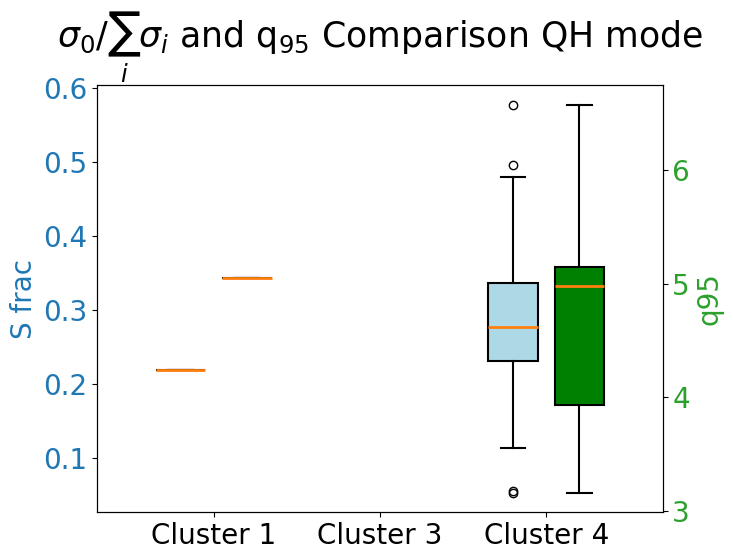

In [165]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare data (excluding cluster '2')
s_data = [S_over_sum_S_QH[c] for c in S_over_sum_S_QH if c != '2']
q_data = [QH_mode_q95_dict[c] for c in QH_mode_q95_dict if c != '2']
labels = [f"Cluster {c}" for c in S_over_sum_S_QH if c != '2']

fig, ax1 = plt.subplots(figsize=(8, 6))

# Define positions for the boxes to avoid overlap
# [0.8, 1.8, ...] for the first set, [1.2, 2.2, ...] for the second
positions_s = np.arange(1, len(s_data) + 1) - 0.2
positions_q = np.arange(1, len(q_data) + 1) + 0.2

# 2. Plot first axis (S frac)
bp1 = ax1.boxplot(s_data, positions=positions_s, widths=0.3, 
                  patch_artist=True, **boxplot_style)
ax1.set_xlabel('', fontsize=20)
ax1.set_ylabel('S frac', color='tab:blue', fontsize=20)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# 3. Create second axis (q95)
ax2 = ax1.twinx()
bp2 = ax2.boxplot(q_data, positions=positions_q, widths=0.3, 
                  patch_artist=True, **boxplot_style)
ax2.set_ylabel('q95', color='tab:green', fontsize=20)
ax2.tick_params(axis='y', labelcolor='tab:green')

# 4. Cleanup and Labels
ax1.set_xticks(np.arange(1, len(labels) + 1))
ax1.set_xticklabels(labels)
plt.title(r'$\sigma_0/ \sum_i \sigma_i$ and q$_{95}$ Comparison QH mode', fontsize=25)

# Optional: Color the boxes differently to match the axes
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')
for patch in bp2['boxes']:
    patch.set_facecolor('green')

plt.tight_layout()

# plt.savefig('Paper_figures/combined_QH_boxplot.pdf', dpi=600)
plt.show()

# We would like to do within cluster comparison of clusters with a mix of regimes

In [166]:
NBI_cluster_dict = cluster_func.cluster_comparison(NBI_dict, cluster_dict_new, signals = True)
NBI_cluster_1_dict = in_cluster_comparison(NBI_dict, cluster_dict_new, bes_dict, 1)
NBI_cluster_2_dict = in_cluster_comparison(NBI_dict, cluster_dict_new, bes_dict, 2)
NBI_cluster_3_dict = in_cluster_comparison(NBI_dict, cluster_dict_new, bes_dict, 3)
if num_clusters_new > 3:
    NBI_cluster_4_dict = in_cluster_comparison(NBI_dict, cluster_dict_new, bes_dict, 4)


missing 0 of 3876 keys
missing 0 of 3876 keys
missing 0 of 3876 keys
missing 0 of 3876 keys


In [167]:
def numfmt_mega(x, pos):
    s = f'{x/10**6}'
    return s

yfmt_mega = tkr.FuncFormatter(numfmt_mega)

def numfmt_kila(x, pos):
    s = f'{x/10**3}'
    return s

yfmt_kila = tkr.FuncFormatter(numfmt_kila)


# SHAP analysis

# The H98 dict contains np.inf's which xgboost does not like. Need to change these to np.nan

In [168]:
for id in h98_dict.keys():
    if h98_dict[id] == np.inf:
        h98_dict[id] = np.nan

# Pedestal width, gradient, height added as features. Also add favorable vs. unfavorable drift direction

In [169]:
pedestal_height_dict = np.load('elm_free_bes_data/pedestal_heights.npy', allow_pickle = True).item()

pe_wid_dict = {id: pedestal_dict[id]['pe']['foot'] - pedestal_dict[id]['pe']['top'] for id in pedestal_dict.keys() if len(pedestal_dict[id]) != 0}
ne_wid_dict = {id: pedestal_dict[id]['ne']['foot'] - pedestal_dict[id]['ne']['top'] for id in pedestal_dict.keys() if len(pedestal_dict[id]) != 0}
te_wid_dict = {id: pedestal_dict[id]['te']['foot'] - pedestal_dict[id]['te']['top'] for id in pedestal_dict.keys() if len(pedestal_dict[id]) != 0}


pe_height_dict = {id: pedestal_height_dict[id]['pe']  for id in pedestal_height_dict.keys() if pedestal_height_dict[id]['pe'] != 0}
ne_height_dict = {id: pedestal_height_dict[id]['ne']  for id in pedestal_height_dict.keys() if pedestal_height_dict[id]['ne'] != 0}
te_height_dict = {id: pedestal_height_dict[id]['te']  for id in pedestal_height_dict.keys() if pedestal_height_dict[id]['te'] != 0}

pe_gradient_dict = {id: pedestal_height_dict[id]['pe']/pe_wid_dict[id] for id in pedestal_height_dict.keys() if id in pe_wid_dict.keys() and pe_wid_dict[id] != 0.0}
te_gradient_dict = {id: pedestal_height_dict[id]['te']/te_wid_dict[id] for id in pedestal_height_dict.keys() if id in pe_wid_dict.keys() and te_wid_dict[id] != 0.0}
ne_gradient_dict = {id: pedestal_height_dict[id]['ne']/ne_wid_dict[id] for id in pedestal_height_dict.keys() if id in pe_wid_dict.keys() and ne_wid_dict[id] != 0.0}


for id in event_ids:
    try:
        pe_wid_dict[id]
    except:
        pe_wid_dict[id] = 'NA'
    try:
        ne_wid_dict[id]
    except:
        ne_wid_dict[id] = 'NA'
    try:
        te_wid_dict[id]
    except:
        te_wid_dict[id] = 'NA'


#favorable vs. unfavorable drif can be determined as follows: if Bt * Ip * drsep > 0: favorable, else unfavorable
drift_direction_dict = {id: np.sign(bt_dict[id]*ip_dict[id]*drsep_dict[id]) for id in event_ids if drsep_dict[id] != 'NA'}

In [170]:
dict_list = [q95_dict, tritop_dict, tribot_dict, kappa_dict, bt_mag_dict, ip_mag_dict, drsep_dict, betan_dict, NBI_dict, torque_dict, 
             h98_dict, S_sum_S_dict, pe_height_dict, te_height_dict, ne_height_dict,  pe_wid_dict, te_wid_dict, ne_wid_dict,
             pe_gradient_dict, te_gradient_dict, ne_gradient_dict, drift_direction_dict]
names = ['$q_{95}$', r'$\delta_t$', r'$\delta_b$', r'$\kappa$', r'$|\text{B}_\text{t}|$', 
         r'$|\text{I}_\text{p}|$', r'dr_$\text{sep}$', r'$\beta_n$', 'NBI', 'torque', r'$\text{H}_{98}$', 
         r'$\sigma_0/ \sum_i \sigma_i$', r'P$_e$', r'T$_e$', r'n$_e$', 
         r'P$_e \text{width}$', r'T$_e \text{width}$', r'n$_e \text{width}$',
         r'$\nabla$ P$_e$', r'$\nabla$ T$_e$', r'$\nabla$ n$_e$', 'drift direction']

#need to reshape the cluster dict so each id has a label of which cluster it's in associated with it
cluster_dict_reshape = {}
clusters = sorted(list(cluster_dict_new.keys()))
cluster_conversion = {cluster: idx for idx,cluster in enumerate(clusters)}
for cluster in clusters:
    ids = cluster_dict_new[cluster]
    temp = {id: cluster_conversion[cluster] for id in ids}
    cluster_dict_reshape.update(temp)
cluster_df = pd.DataFrame({'Cluster': pd.Series(cluster_dict_reshape)})

In [171]:
for num,dictionary in enumerate(dict_list):
    num_missing = 0
    for id in event_ids:
        if isinstance(dictionary[id], dict):
            nested_keys = list(dictionary[id].keys())
            for nested_key in nested_keys:
                data = dictionary[id][nested_key]
                if isinstance(data, str) or data == np.nan or data == np.inf:
                    num_missing += 1
        else:
            if isinstance(dictionary[id], str):
                num_missing += 1
    print(f'num missing for {names[num]} is {num_missing}')

num missing for $q_{95}$ is 0
num missing for $\delta_t$ is 0
num missing for $\delta_b$ is 0
num missing for $\kappa$ is 0
num missing for $|\text{B}_\text{t}|$ is 0
num missing for $|\text{I}_\text{p}|$ is 0
num missing for dr_$\text{sep}$ is 0
num missing for $\beta_n$ is 0
num missing for NBI is 0
num missing for torque is 0
num missing for $\text{H}_{98}$ is 25
num missing for $\sigma_0/ \sum_i \sigma_i$ is 0
num missing for P$_e$ is 0
num missing for T$_e$ is 0
num missing for n$_e$ is 0
num missing for P$_e \text{width}$ is 0
num missing for T$_e \text{width}$ is 0
num missing for n$_e \text{width}$ is 0
num missing for $\nabla$ P$_e$ is 0
num missing for $\nabla$ T$_e$ is 0
num missing for $\nabla$ n$_e$ is 0
num missing for drift direction is 0


Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV 1/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.963 total time=   0.1s


/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 2/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.926 total time=   0.1s
[CV 3/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.940 total time=   0.1s
[CV 4/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.817 total time=   0.1s
[CV 5/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.874 total time=   0.1s
[CV 6/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.914 total time=   0.1s
[CV 7/10] 

[CV 9/10] END colsample_bytree=0.5779972601681014, learning_rate=0.026844247528777843, max_depth=6, min_child_weight=4, n_estimators=89, subsample=0.8540362888980227;, score=0.940 total time=   0.2s
[CV 10/10] END colsample_bytree=0.5779972601681014, learning_rate=0.026844247528777843, max_depth=6, min_child_weight=4, n_estimators=89, subsample=0.8540362888980227;, score=0.960 total time=   0.2s
[CV 1/10] END colsample_bytree=0.5102922471479012, learning_rate=0.29127385712697834, max_depth=5, min_child_weight=6, n_estimators=87, subsample=0.5003893829205072;, score=0.963 total time=   0.1s
[CV 2/10] END colsample_bytree=0.5102922471479012, learning_rate=0.29127385712697834, max_depth=5, min_child_weight=6, n_estimators=87, subsample=0.5003893829205072;, score=0.947 total time=   0.1s
[CV 3/10] END colsample_bytree=0.5102922471479012, learning_rate=0.29127385712697834, max_depth=5, min_child_weight=6, n_estimators=87, subsample=0.5003893829205072;, score=0.934 total time=   0.1s
[CV 4/1

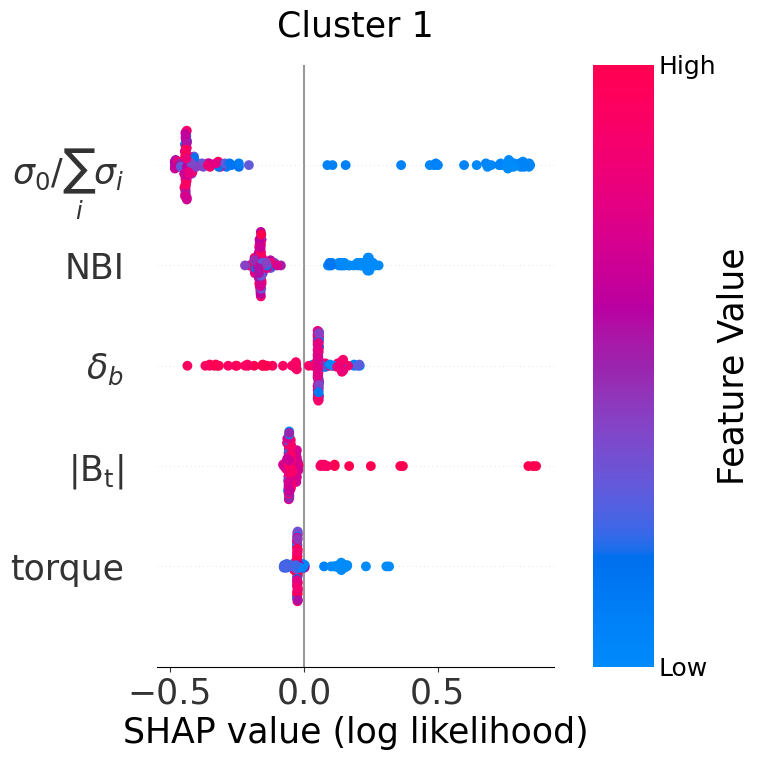

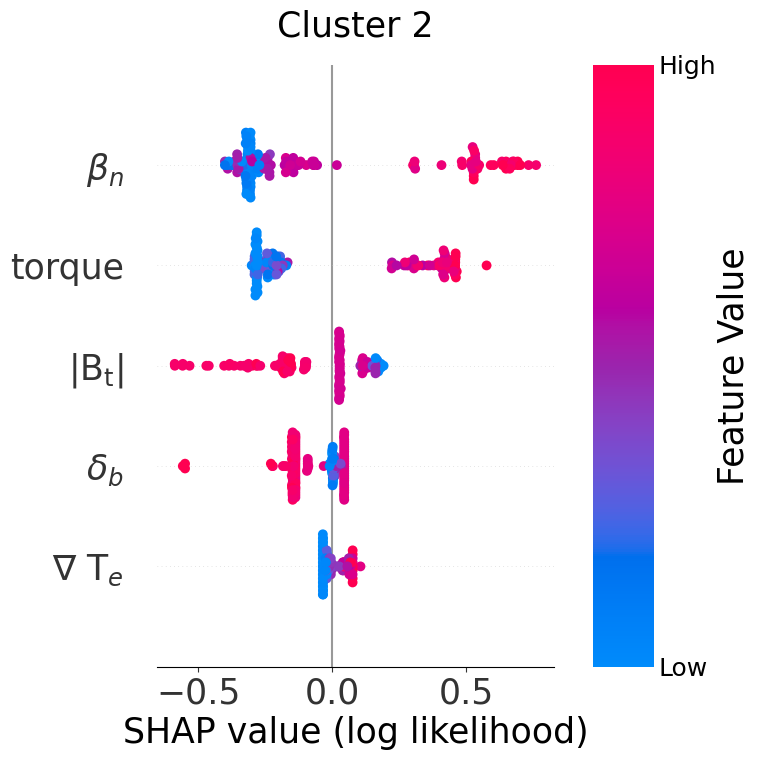

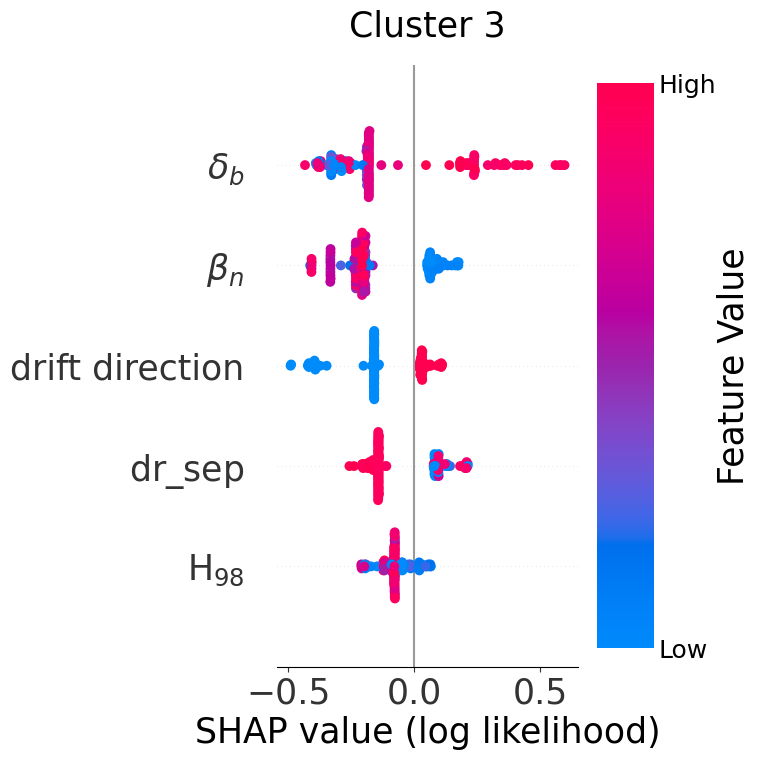

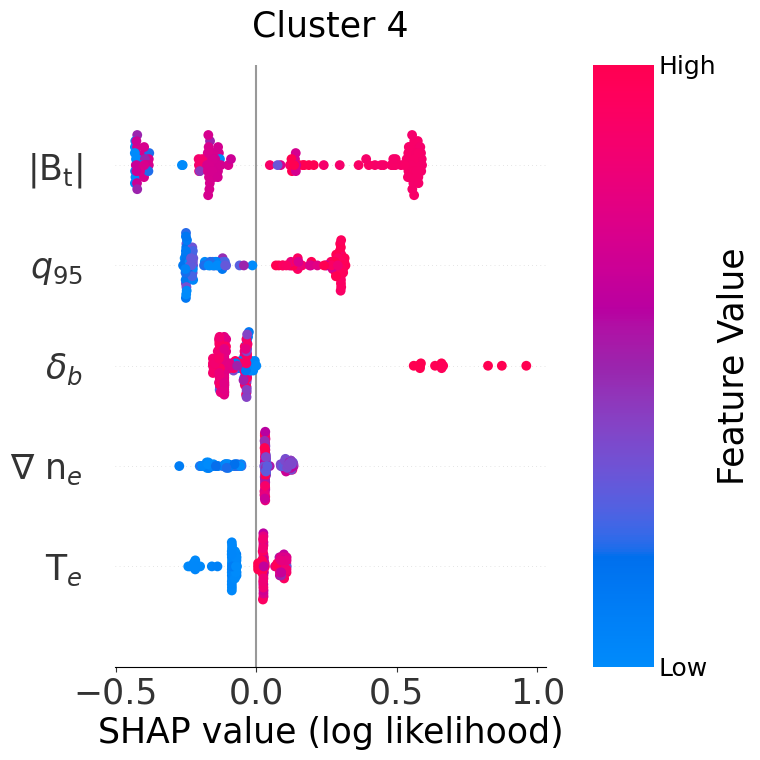

In [172]:
ids = list(cluster_dict_reshape.keys())


feature_dataframe = cluster_func.to_dataframe(dict_list, names, ids)


shap_figs, shap_axes = cluster_func.SHAP_analysis(feature_dataframe, cluster_df, num_clusters_new, return_fig=True)

# QH mode SHAP analysis

In [173]:

#need to reshape the cluster dict so each id has a label of which cluster it's in associated with it
cluster_dict_reshape_QH = {}
clusters = sorted(list(cluster_dict_new.keys()))
cluster_conversion = {cluster: idx for idx,cluster in enumerate(clusters)}
ids_QH = []
for cluster in clusters:
    ids = cluster_dict_new[cluster]
    temp = {}
    for id in ids:
        cluster_bool = cluster == '2' or cluster == '3' or cluster == '4'
        if bes_dict[id]['label'] == 2 and cluster_bool:
            temp[id] = cluster_conversion[cluster]
            ids_QH.append(id)
    cluster_dict_reshape_QH.update(temp)
cluster_df_QH = pd.DataFrame({'Cluster': pd.Series(cluster_dict_reshape_QH)})

In [174]:
QH_feature_dataframe = cluster_func.to_dataframe(dict_list, names, ids_QH)



QH_fig, QH_axes = cluster_func.SHAP_analysis(QH_feature_dataframe, cluster_df_QH, 3, return_fig=True)

/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV 1/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.961 total time=   0.0s
[CV 2/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.909 total time=   0.0s
[CV 3/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=1.000 total time=   0.0s
[CV 4/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=1.000 total time=   0.0s
[CV 5/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample

[CV 1/10] END colsample_bytree=0.5070399113575422, learning_rate=0.0676642971857535, max_depth=4, min_child_weight=3, n_estimators=82, subsample=0.8029799873905057;, score=0.961 total time=   0.0s
[CV 2/10] END colsample_bytree=0.5070399113575422, learning_rate=0.0676642971857535, max_depth=4, min_child_weight=3, n_estimators=82, subsample=0.8029799873905057;, score=0.909 total time=   0.0s
[CV 3/10] END colsample_bytree=0.5070399113575422, learning_rate=0.0676642971857535, max_depth=4, min_child_weight=3, n_estimators=82, subsample=0.8029799873905057;, score=1.000 total time=   0.0s
[CV 4/10] END colsample_bytree=0.5070399113575422, learning_rate=0.0676642971857535, max_depth=4, min_child_weight=3, n_estimators=82, subsample=0.8029799873905057;, score=1.000 total time=   0.0s
[CV 5/10] END colsample_bytree=0.5070399113575422, learning_rate=0.0676642971857535, max_depth=4, min_child_weight=3, n_estimators=82, subsample=0.8029799873905057;, score=0.960 total time=   0.0s
[CV 6/10] END c

IndexError: too many indices for array

In [ ]:
# 1. Prepare data (excluding cluster '2')
def pastel_boxplot(data_dict, clusters_given, y_axis, title = None, return_fig = False):
    '''
    Function for making pastel blue boxplots for parameter dict

    data_dict: dict where each key is a cluster label ('1', '2', etc.), and each value is a list containing the values of a parameter
    in that cluster
    clusters_given: list of strings. Clusters to include in boxplot
    y_axis: str. y axis label for the plot
    title: default None. Else, a string used for the title of the plot
    return_fig: default False. Can be used to return the figure for saving later
    '''
    data = [data_dict[cluster] for cluster in QH_mode_torque_dict if cluster in clusters_given]

    labels = [f"Cluster {c}" for c in clusters_given]

    fig, ax1 = plt.subplots(figsize=(8, 6))

    bp1 = ax1.boxplot(data, widths=0.3, 
                    patch_artist=True, **boxplot_style)
    ax1.set_xlabel('', fontsize=20)
    ax1.set_ylabel(y_axis, fontsize=20)
    ax1.tick_params(axis='y')


    ax1.set_xticks(np.arange(1, len(labels) + 1))
    ax1.set_xticklabels(labels)
    if title:
        plt.title(title, fontsize=25)


    for patch in bp1['boxes']:
        patch.set_facecolor('lightblue')

    plt.tight_layout()
    

    plt.show()
    if return_fig:
        return plt.gcf()

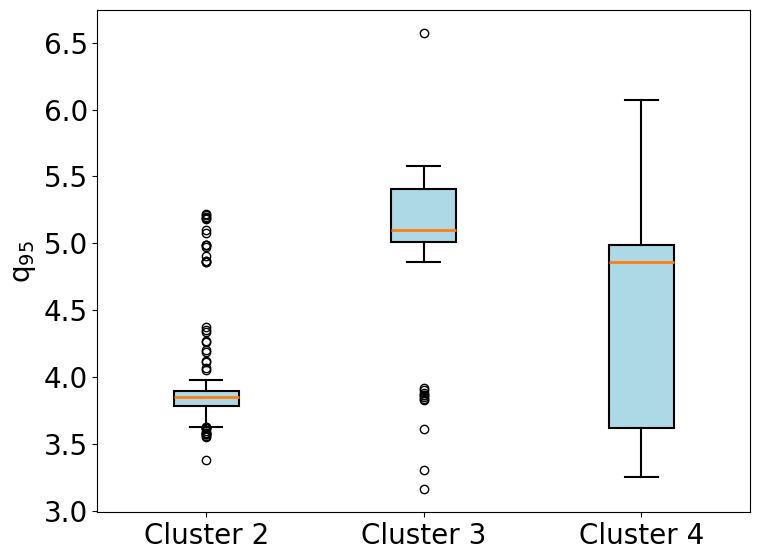

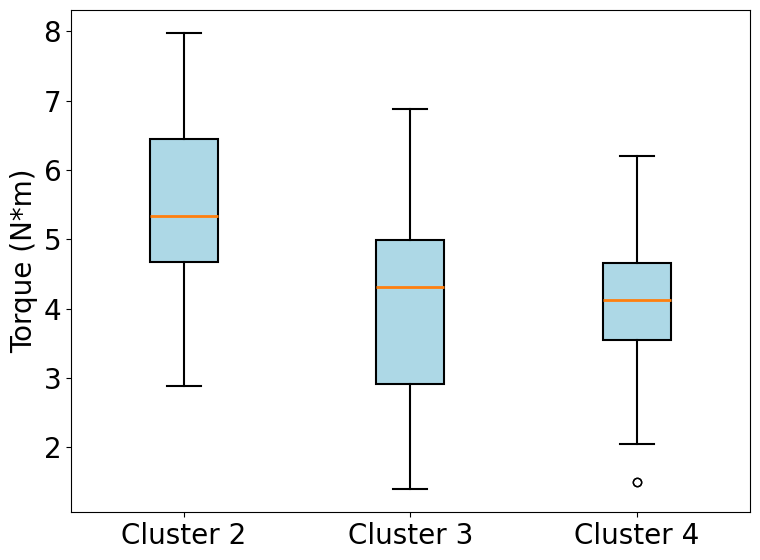

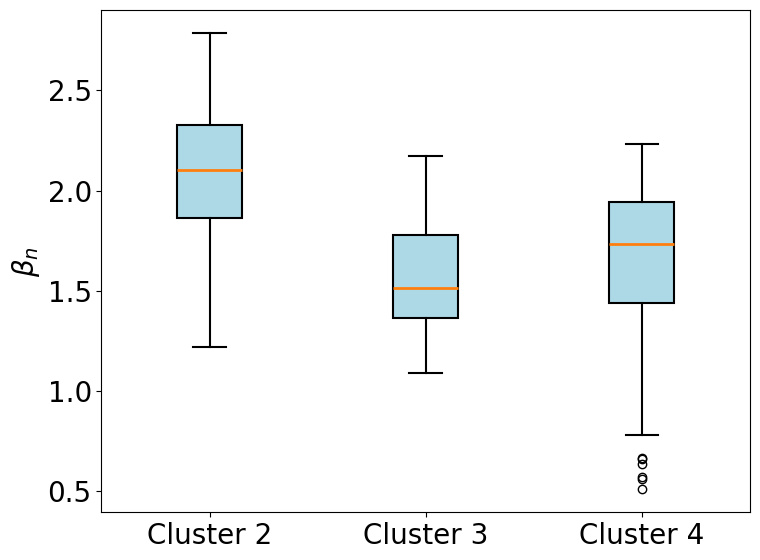

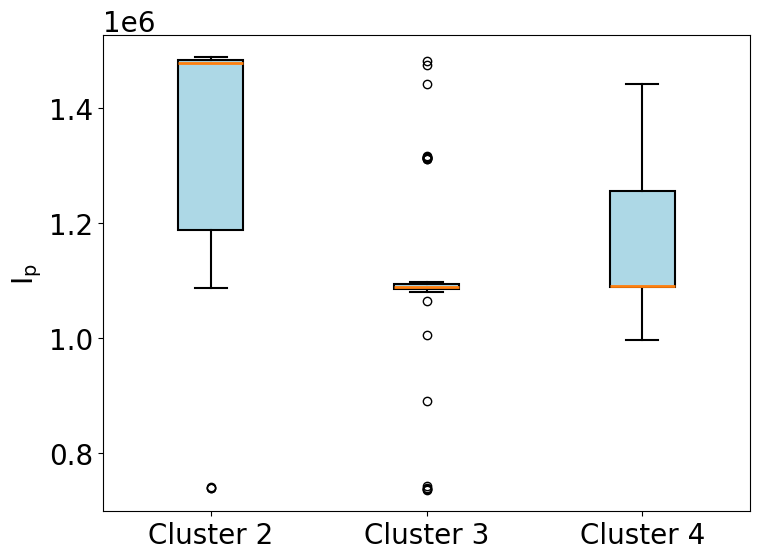

In [ ]:
pastel_boxplot(QH_mode_q95_dict, ['2', '3', '4'], y_axis = r'q$_{95}$')
pastel_boxplot(QH_mode_torque_dict, ['2', '3', '4'], y_axis = r'Torque (N*m)')
pastel_boxplot(QH_mode_betan_dict, ['2', '3', '4'], y_axis = r'$\beta_n$')
pastel_boxplot(QH_mode_mag_ip_dict, ['2', '3', '4'], y_axis = r'$\text{I}_{\text{p}}$')
# pastel_boxplot(QH_mode_, ['2', '3', '4'], y_axis = r'Torque (N*m)')


In [ ]:
# for k,i in enumerate(QH_fig):
#     i.savefig(f'Paper_figures/SHAP_QH_cluster_{k+1}_BES.pdf', dpi = 600)

# WPQH mode SHAP analysis

In [ ]:

#need to reshape the cluster dict so each id has a label of which cluster it's in associated with it
cluster_dict_reshape_WPQH = {}
clusters = sorted(list(cluster_dict_new.keys()))
cluster_conversion = {cluster: idx for idx,cluster in enumerate(clusters)}
ids_WPQH = []
for cluster in clusters:
    ids = cluster_dict_new[cluster]
    temp = {}
    for id in ids:
        cluster_bool = cluster == '3' or cluster == '4'
        if bes_dict[id]['label'] == 3 and cluster_bool:
            temp[id] = cluster_conversion[cluster]
            ids_WPQH.append(id)
    cluster_dict_reshape_WPQH.update(temp)
cluster_df_WPQH = pd.DataFrame({'Cluster': pd.Series(cluster_dict_reshape_WPQH)})

In [ ]:
# #FIXME try WPQH mode SHAP analysis across all clusters
# cluster_dict_reshape_WPQH = {}
# clusters = sorted(list(cluster_dict_new.keys()))
# cluster_conversion = {}
# for idx,cluster in enumerate(clusters):
#     if cluster == '3':
#         cluster_conversion[cluster] = idx
#     elif cluster == '1' or '2' or '4':
#         cluster_conversion['2'] = idx

# ids_WPQH = []
# for cluster in clusters:
#     ids = cluster_dict_new[cluster]
#     temp = {}
#     for id in ids:
#         primary_cluster_bool = cluster == '3' 
#         if bes_dict[id]['label'] == 3 and primary_cluster_bool:
#             temp[id] = cluster_conversion[cluster]
#             ids_WPQH.append(id)
#         elif bes_dict[id]['label'] == 3 and not primary_cluster_bool:
#             temp[id] = cluster_conversion['2']
#             ids_WPQH.append(id)
#     cluster_dict_reshape_WPQH.update(temp)
# cluster_df_WPQH = pd.DataFrame({'Cluster': pd.Series(cluster_dict_reshape_WPQH)})

In [ ]:
print(cluster_dict_reshape_WPQH.keys())

dict_keys([np.str_('00042'), np.str_('00894'), np.str_('00895'), np.str_('00896'), np.str_('00897'), np.str_('00898'), np.str_('00899'), np.str_('00900'), np.str_('00901'), np.str_('00903'), np.str_('00904'), np.str_('00905'), np.str_('00906'), np.str_('00907'), np.str_('00908'), np.str_('00910'), np.str_('00911'), np.str_('00914'), np.str_('00915'), np.str_('00916'), np.str_('00917'), np.str_('00918'), np.str_('00919'), np.str_('00920'), np.str_('00921'), np.str_('00922'), np.str_('00923'), np.str_('01117'), np.str_('01118'), np.str_('01120'), np.str_('01121'), np.str_('01226'), np.str_('01227'), np.str_('01228'), np.str_('01229'), np.str_('01230'), np.str_('01231'), np.str_('01232'), np.str_('01233'), np.str_('01234'), np.str_('01239'), np.str_('01240'), np.str_('01241'), np.str_('01242'), np.str_('01243'), np.str_('01244'), np.str_('01245'), np.str_('01250'), np.str_('01251'), np.str_('01252'), np.str_('01253'), np.str_('01254'), np.str_('01255'), np.str_('01415'), np.str_('01416'),

Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV 1/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.960 total time=   0.0s
[CV 2/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.960 total time=   0.0s
[CV 3/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=1.000 total time=   0.0s
[CV 4/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=1.000 total time=   0.0s
[CV 5/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample

/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


[CV 8/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=1.000 total time=   0.0s
[CV 9/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.286 total time=   0.0s
[CV 10/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.265 total time=   0.0s
[CV 1/10] END colsample_bytree=0.5779972601681014, learning_rate=0.026844247528777843, max_depth=6, min_child_weight=4, n_estimators=89, subsample=0.8540362888980227;, score=0.960 total time=   0.0s
[CV 2/10] END colsample_bytree=0.5779972601681014, learning_rate=0.026844247528777843, max_depth=6, min_child_weight=4, n_estimators=89, subsample=0.8540362888980227;, score=0.960 total time=   0.0s
[CV 3/1

/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


mean cv score: 0.6337474120082816
[[25  0]
 [ 3  0]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        25
           1       0.00      0.00      0.00         3

    accuracy                           0.89        28
   macro avg       0.45      0.50      0.47        28
weighted avg       0.80      0.89      0.84        28



/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

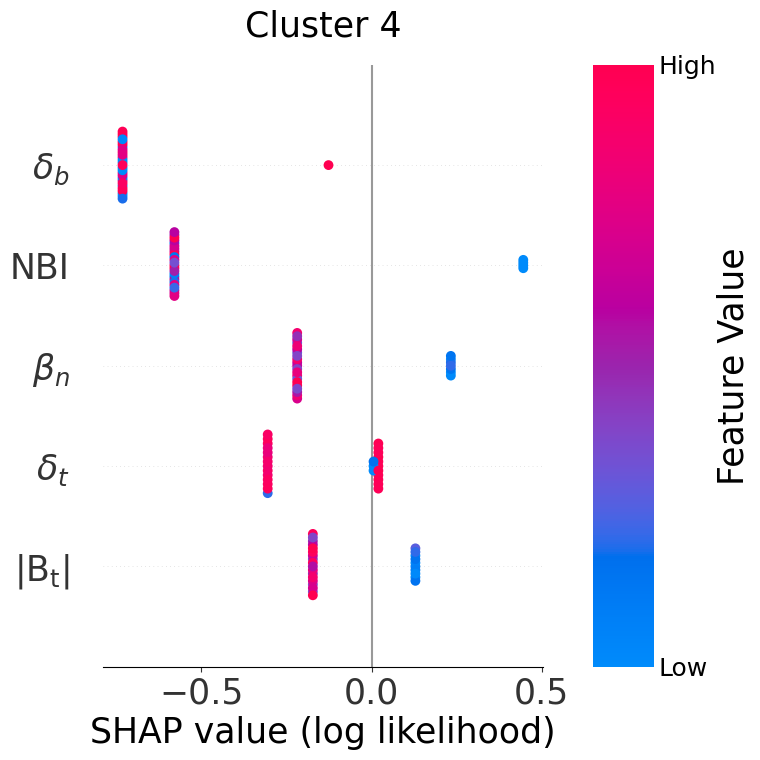

In [ ]:
feature_dataframe = cluster_func.to_dataframe(dict_list, names, ids_WPQH)



WPQH_fig, WPQH_axes = cluster_func.SHAP_analysis(feature_dataframe, cluster_df_WPQH, 2, return_fig=True)

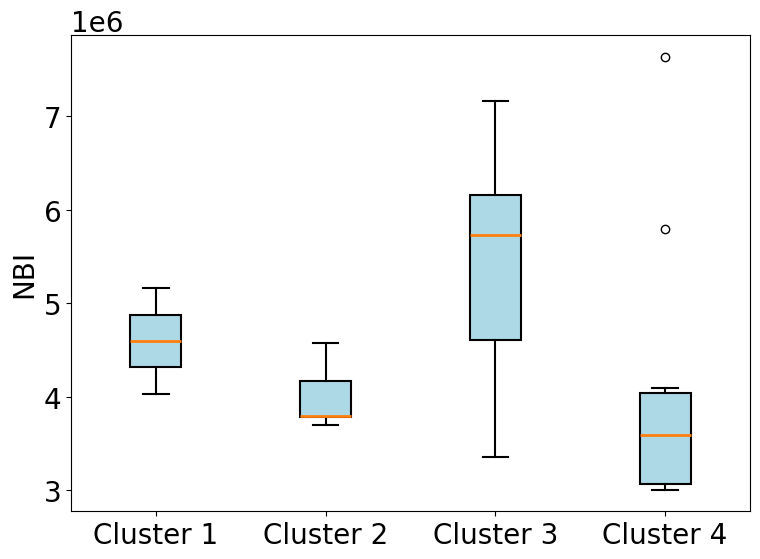

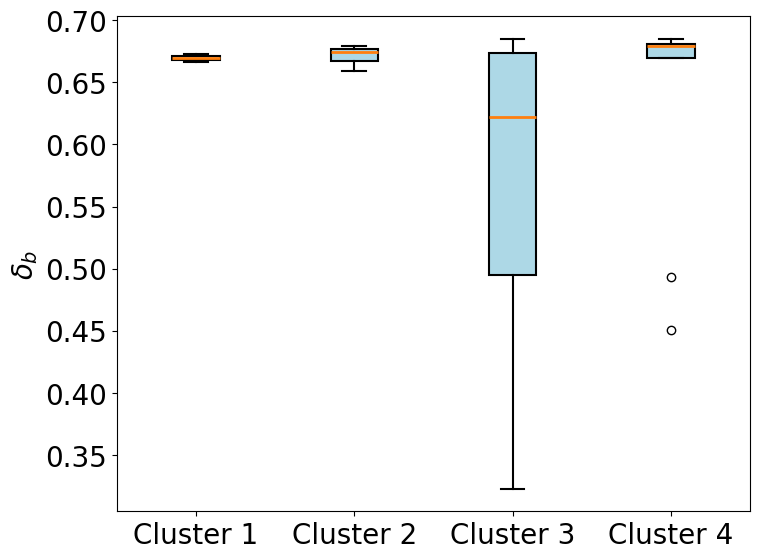

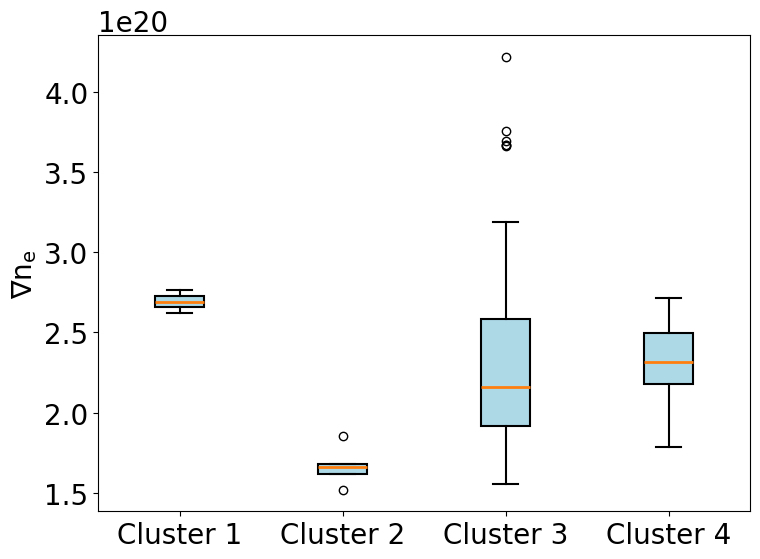

In [ ]:
pastel_boxplot(WPQH_mode_NBI_dict, ['1', '2', '3', '4'], y_axis = r'NBI')
pastel_boxplot(WPQH_mode_tribot_dict, ['1', '2', '3', '4'], y_axis = r'$\delta_b$')
pastel_boxplot(WPQH_mode_ne_gradient_dict, ['1', '2', '3', '4'], y_axis = r'$\nabla \text{n}_\text{e}$')


In [ ]:
# for k,i in enumerate(WPQH_fig):
#     i.savefig(f'Paper_figures/SHAP_WPQH_cluster_{k+1}_BES.pdf', dpi = 600)

# L mode SHAP analysis

In [ ]:
#FIXME try L mode SHAP analysis across all clusters
#need to reshape the cluster dict so each id has a label of which cluster it's in associated with it
cluster_dict_reshape_L = {}
clusters = sorted(list(cluster_dict_new.keys()))
cluster_conversion = {cluster: idx for idx,cluster in enumerate(clusters)}
ids_L = []
for cluster in clusters:
    ids = cluster_dict_new[cluster]
    temp = {}
    for id in ids:
        cluster_bool = cluster == '1' or cluster == '2' 
        if bes_dict[id]['label'] == 0 and cluster_bool:
            temp[id] = cluster_conversion[cluster]
            ids_L.append(id)
    cluster_dict_reshape_L.update(temp)
cluster_df_L = pd.DataFrame({'Cluster': pd.Series(cluster_dict_reshape_L)})

/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV 1/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.857 total time=   0.0s
[CV 2/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.844 total time=   0.0s
[CV 3/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=1.000 total time=   0.0s
[CV 4/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=1.000 total time=   0.0s
[CV 5/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample

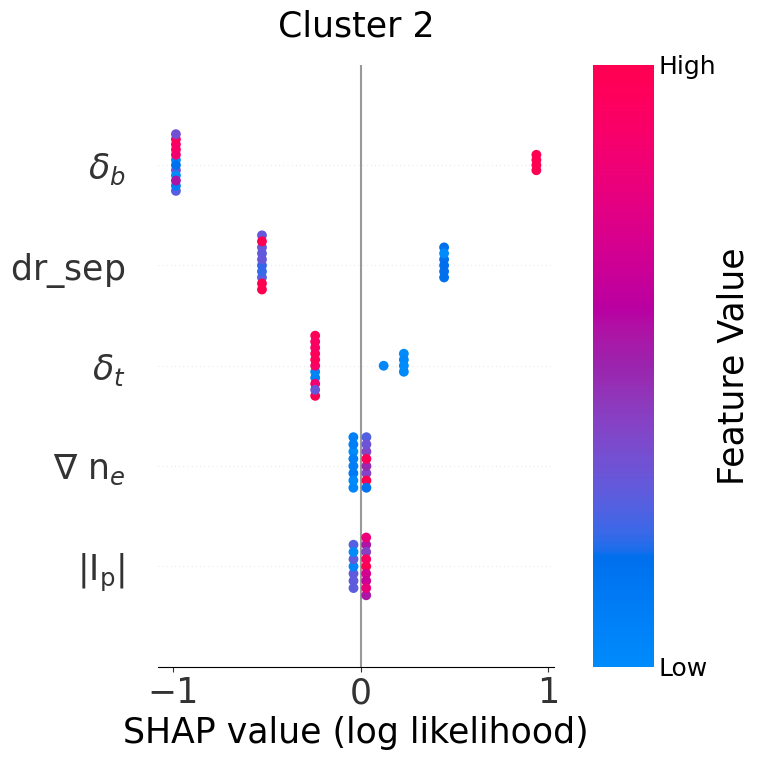

In [ ]:
L_feature_dataframe = cluster_func.to_dataframe(dict_list, names, ids_L)



L_fig, L_axs = cluster_func.SHAP_analysis(L_feature_dataframe, cluster_df_L, 2, return_fig=True)

In [ ]:
# for k,i in enumerate(L_fig):
#     i.savefig(f'Paper_figures/SHAP_L_cluster_{k+1}_BES.pdf', dpi = 600)

# Kevin Gill from UW Madison sent me the shots that he used for testing his NN. I would like to compare his results with my own to see if the same QH and WPQH shots are confused

In [ ]:
test_shots_from_kevin = ['190863' '164869' '184440' '169332' '159174' '185920' '159562' '163508'

'192767' '195649' '184467' '189315' '169379' '191030' '185503' '189196'

'175555' '169849' '179720' '174631' '184461' '189650' '164872' '187036'

'171473' '192710' '182665' '175591' '195948' '159175' '175527' '169873'

'175826' '184434' '180536' '185497' '167588' '159544' '159543' '189602'

'163460' '149996' '164884' '163505']